In [ ]:
import pandas as pd
import numpy as np
import os
import sys

In [ ]:
gcn_mlp_results_df= pd.read_csv("TimeDistributedMLP/graph2vec_mlp2_finalresults.csv")

In [ ]:
metric = "spearman"


In [ ]:
# Create ablate_z boolean column: True for no_emb rows, False for graph2vec rows
gcn_mlp_results_df['ablate_z'] = gcn_mlp_results_df['metric'] == 'ablate_z'

# Restore metric column: no_emb rows back to "no_emb", spearman rows use the metric variable
gcn_mlp_results_df.loc[gcn_mlp_results_df['ablate_z'], 'metric'] = 'no_emb'
gcn_mlp_results_df.loc[~gcn_mlp_results_df['ablate_z'], 'metric'] = metric

print(gcn_mlp_results_df[['metric', 'ablate_z']].value_counts())

metric    ablate_z
spearman  False       367
Name: count, dtype: int64


In [ ]:
gcn_mlp_results_df[gcn_mlp_results_df['threshold'].isna()].assign(threshold='0.75')
gcn_mlp_results_df[gcn_mlp_results_df['enable_edges'].isna()].assign(enable_edges=True)



In [ ]:
gcn_mlp_results_df

,item_id,store_id,seed,metric,window_size,step_size,threshold,percentile,enable_edges,enable_second_degree,rmse,mae,bias,r2_score,pocid,train_time,inference_time,best_epoch,ablate_z,composite_score
0,26220,6269.00,42.0,spearman,15.0,1.0,NaN,NaN,NaN,NaN,43.491232,30.671218,2.063701,0.354756,0.598684,31.0287,0.027,439.0,False,0.354756
1,26220,6269.00,42.0,spearman,15.0,1.0,0.75,NaN,True,False,38.379501,26.901772,3.923065,0.497520,0.532895,19.4164,1.065,226.0,False,0.497520
2,26220,6269.00,42.0,spearman,15.0,1.0,0.82,NaN,True,False,44.035323,30.535819,5.544089,0.338511,0.572368,15.7887,0.304,164.0,False,0.338511
3,26220,6269.00,42.0,spearman,15.0,1.0,0.85,NaN,True,False,50.004861,32.075852,-3.699083,0.147008,0.506579,14.8760,0.234,164.0,False,0.147008
4,26220,6269.00,42.0,spearman,15.0,1.0,0.88,NaN,True,False,48.250940,30.462708,-4.939247,0.205796,0.513158,17.0655,0.238,212.0,False,0.205796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,213624,6269.00,42.0,spearman,15.0,1.0,0.82,NaN,True,False,9.631496,7.485329,-0.382485,0.262050,0.644737,9.0082,0.289,46.0,False,0.262050
363,213624,6269.00,42.0,spearman,15.0,1.0,0.85,NaN,True,False,10.736228,8.610814,1.265121,0.083056,0.572368,19.1540,0.333,249.0,False,0.083056
364,213624,6269.00,42.0,spearman,15.0,1.0,0.88,NaN,True,False,9.571119,7.512559,-0.745366,0.271273,0.638158,9.2383,0.218,41.0,False,0.271273
365,213624,6269.00,42.0,spearman,15.0,1.0,0.91,NaN,True,False,9.419336,7.371126,-0.290461,0.294203,0.677632,9.1587,0.213,46.0,False,0.294203


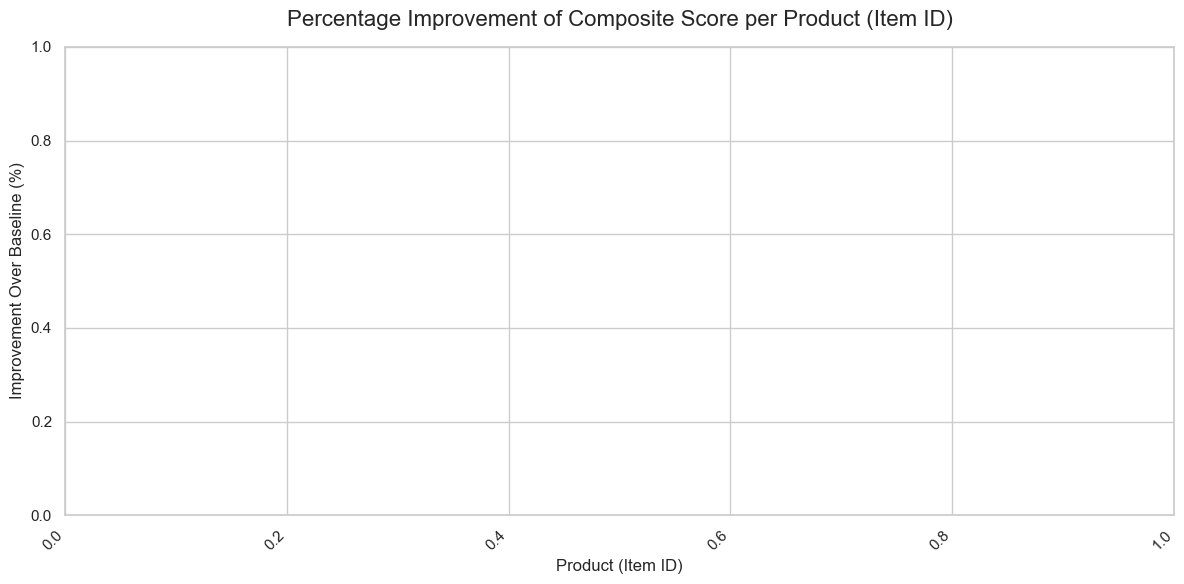

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Define the Composite Score
gcn_mlp_results_df['composite_score'] = gcn_mlp_results_df['r2_score']

# 3. Separate Baseline and Experimental models
# Baseline is where ablate_z == True (no_emb rows)
baseline_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == True].copy()
baseline_scores = baseline_df.groupby('item_id')['composite_score'].mean().reset_index()
baseline_scores.rename(columns={'composite_score': 'baseline_score'}, inplace=True)

# 4. Get the best experimental score per item
# ablate_z == False is the graph2vec model
experimental_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == False].copy()
best_exp_scores = experimental_df.groupby('item_id')['composite_score'].max().reset_index()
best_exp_scores.rename(columns={'composite_score': 'best_experimental_score'}, inplace=True)

# 5. Merge and Calculate Percentage Improvement
improvement_df = pd.merge(baseline_scores, best_exp_scores, on='item_id')

# Formula for R2 (higher is better): ((Experimental - Baseline) / abs(Baseline)) * 100
improvement_df['pct_improvement'] = (
    (improvement_df['best_experimental_score'] - improvement_df['baseline_score']) 
    / improvement_df['baseline_score'].abs()
) * 100

# Sort for a nicer looking plot
improvement_df = improvement_df.sort_values(by='pct_improvement', ascending=False)

# 6. Plotting with Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=improvement_df, 
    x='item_id', 
    y='pct_improvement', 
    palette='viridis',
    order=improvement_df['item_id']
)

plt.title('Percentage Improvement of Composite Score per Product (Item ID)', fontsize=16, pad=15)
plt.xlabel('Product (Item ID)', fontsize=12)
plt.ylabel('Improvement Over Baseline (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Load your DataFrame (assuming you've already run this)
# gcn_mlp_results_df = pd.read_csv("../GCN/TimedistributedMLP/gcn_mlp_final_results.csv")

# 2. Define the Composite Score
# For R2 score, HIGHER is better.
gcn_mlp_results_df['composite_score'] = gcn_mlp_results_df['r2_score']

# 3. Separate Baseline and Experimental models
# Assuming the baseline is the model where ablate_z == True
baseline_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == True].copy()
baseline_scores = baseline_df.groupby('item_id')['composite_score'].mean().reset_index()
baseline_scores.rename(columns={'composite_score': 'baseline_score'}, inplace=True)

# 4. Get the best experimental score per item
experimental_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == False].copy()
# Note: Because R2 is higher-is-better, we use .max() instead of .min()
best_exp_scores = experimental_df.groupby('item_id')['composite_score'].max().reset_index()
best_exp_scores.rename(columns={'composite_score': 'best_experimental_score'}, inplace=True)

# 5. Merge and Calculate Percentage Improvement
improvement_df = pd.merge(baseline_scores, best_exp_scores, on='item_id')

# Formula for metrics where higher is better: ((Experimental - Baseline) / abs(Baseline)) * 100
improvement_df['pct_improvement'] = (
    (improvement_df['best_experimental_score'] - improvement_df['baseline_score']) 
    / improvement_df['baseline_score'].abs()
) * 100

# Sort so the highest improvements are at the top
improvement_df = improvement_df.sort_values(by='pct_improvement', ascending=False)

# 6. Display as a styled table
# This will render a colored HTML table in your Jupyter Notebook
styled_table = improvement_df.style.format({
    'baseline_score': '{:.4f}',
    'best_experimental_score': '{:.4f}',
    'pct_improvement': '{:+.2f}%' # Adds a + sign for positive improvements
}).background_gradient(
    subset=['pct_improvement'], 
    cmap='RdYlGn', # Red (negative) to Yellow (neutral) to Green (positive)
    vmin=-10,      # Adjust these bounds based on your expected variance
    vmax=10
).set_caption(
    "Percentage Improvement of R2 Score per Product (Item ID)"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}]).hide(axis="index")

# Leave the variable at the end of the cell to render it
styled_table

item_id,baseline_score,best_experimental_score,pct_improvement


In [ ]:
import pandas as pd
from IPython.display import display

# 1. Load your DataFrame (assuming you've already run this)
# gcn_mlp_results_df = pd.read_csv("../GCN/TimedistributedMLP/gcn_mlp_final_results.csv")
df = gcn_mlp_results_df.copy()

# Define the metric (Higher is better for R2)
df['composite_score'] = df['r2_score']

# 2. Get the Baseline (Ablation == True)
baseline = df[df['ablate_z'] == True].groupby('item_id')['composite_score'].max().reset_index()
baseline.rename(columns={'composite_score': 'Best_val_for_ablation'}, inplace=True)

# 3. Get Experimental thresholds (Ablation == False) and Pivot
exp = df[df['ablate_z'] == False]
pivot_exp = pd.pivot_table(
    exp, 
    values='composite_score', 
    index='item_id', 
    columns='threshold', 
    aggfunc='max'
).reset_index()

# 4. Merge Baseline and Experimental tables
final_df = pd.merge(baseline, pivot_exp, on='item_id')

# 5. Dynamically calculate relative performance
thresholds = [col for col in pivot_exp.columns if col != 'item_id']

ordered_cols = ['item_id', 'Best_val_for_ablation']
rel_cols_for_styling = [] 

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'
    
    final_df.rename(columns={t: val_col}, inplace=True)
    
    final_df[rel_col] = (
        (final_df[val_col] - final_df['Best_val_for_ablation']) 
        / final_df['Best_val_for_ablation'].abs()
    ) * 100
    
    ordered_cols.extend([val_col, rel_col])
    rel_cols_for_styling.append(rel_col)

final_df = final_df[ordered_cols]

# 6. Apply dynamic styling for the detailed table
format_dict = {col: '{:.4f}' for col in final_df.columns if col.startswith('Best_val')}
format_dict.update({col: '{:+.2f}%' for col in rel_cols_for_styling})

styled_table = final_df.style.format(format_dict).background_gradient(
    subset=rel_cols_for_styling, 
    cmap='RdYlGn', 
    vmin=-10, 
    vmax=10
).set_caption(
    "Absolute Scores and Relative Performance per Threshold vs Ablation Baseline"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#f4f4f4')]
}]).hide(axis="index")


# --- NEW SECTION: SUMMARY TABLE ---

# 7. Calculate aggregate metrics for each threshold
summary_data = []

# Get the average baseline score just for context
mean_baseline = final_df['Best_val_for_ablation'].mean()

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'
    
    mean_score = final_df[val_col].mean()
    mean_improvement = final_df[rel_col].mean()
    # MAPE: Mean of the absolute percentage differences
    mape = final_df[rel_col].abs().mean()
    # Win Rate: What percentage of items saw a positive improvement?
    win_rate = (final_df[rel_col] > 0).mean() * 100 
    
    summary_data.append({
        'Threshold': t,
        'Mean Score (R2)': mean_score,
        'Mean Improvement (%)': mean_improvement,
        'MAPE (%)': mape,
        'Win Rate (%)': win_rate
    })

summary_df = pd.DataFrame(summary_data)

# 8. Style the summary table
styled_summary = summary_df.style.format({
    'Mean Score (R2)': '{:.4f}',
    'Mean Improvement (%)': '{:+.2f}%',
    'MAPE (%)': '{:.2f}%',
    'Win Rate (%)': '{:.1f}%'
}).background_gradient(
    subset=['Mean Improvement (%)', 'Win Rate (%)'], 
    cmap='RdYlGn',
    # Adjust vmin/vmax based on what constitutes a "good" overall average in your domain
    vmin=-2, 
    vmax=2 
).set_caption(
    f"Average Performance Metrics by Threshold (Baseline Avg R2: {mean_baseline:.4f})"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('color', '#333')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#e8f4f8')]
}]).hide(axis="index")

# Display both tables sequentially in the output cell
display(styled_table)
display(styled_summary)

item_id,Best_val_for_ablation,Best_val_for_threshold_0.75,Relative_Performance_for_threshold_0.75,Best_val_for_threshold_0.82,Relative_Performance_for_threshold_0.82,Best_val_for_threshold_0.85,Relative_Performance_for_threshold_0.85,Best_val_for_threshold_0.88,Relative_Performance_for_threshold_0.88,Best_val_for_threshold_0.91,Relative_Performance_for_threshold_0.91


Threshold,Mean Score (R2),Mean Improvement (%),MAPE (%),Win Rate (%)
0.750000,nan,+nan%,nan%,nan%
0.820000,nan,+nan%,nan%,nan%
0.850000,nan,+nan%,nan%,nan%
0.880000,nan,+nan%,nan%,nan%
0.910000,nan,+nan%,nan%,nan%
